In [5]:
import matplotlib.pyplot as plt
import torch
from pathlib import PurePath
import dill as pickle
from config import *
import numpy as np
import scipy
#import pandas as pd

In [6]:
grid_N = 100
grid_N_plot = 33
modelName = "DeflationPINN"

In [13]:
with open(PurePath(pathTrainedModels, modelName +".pkl"), "rb") as f:
    model = pickle.load(f)#.to("cuda:0")

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\seand\\Projects\\DeflationPINNs\\models\\DeflationPINN.pkl'

In [14]:
model


NameError: name 'model' is not defined

In [9]:
def relative_l2_Difference(x1, y1,Q11_1, Q12_1, x2, y2,Q11_2, Q12_2 ):
    '''
    Computes the relative L2 difference of the respective funcitons under the assumption, that the x and y coordinates contain the same values, but in different orderings, i.e. same grid but different ordering of the points in the grid.
    We devide over the norm of the second set of values, i.e. Q11_2 and Q11_2.
    '''

    df1_by_x = pd.DataFrame({"x":x1, "y":y1, "q11":Q11_1.reshape(-1), "q12":Q12_1.reshape(-1)})
    df1_by_x = df1_by_x.sort_values(by=["x", "y"])

    df2_by_x = pd.DataFrame({"x":x2, "y":y2, "q11":Q11_2.reshape(-1), "q12":Q12_2.reshape(-1)})
    df2_by_x = df2_by_x.sort_values(by=["x", "y"])

    q11_1 = df1_by_x["q11"].to_numpy()
    q12_1 = df1_by_x["q12"].to_numpy()

    q11_2 = df2_by_x["q11"].to_numpy()
    q12_2 = df2_by_x["q12"].to_numpy()
    return np.sqrt((np.nanmean( (q11_1 - q11_2)**2 + (q12_1 - q12_2)**2))  / (np.nanmean( ( q11_2)**2 + ( q12_2)**2)) )


def l2_Difference(x1, y1,Q11_1, Q12_1, x2, y2,Q11_2, Q12_2 ):
    '''
    Computes the L2 difference of the respective funcitons under the assumption, that the x and y coordinates contain the same values, but in different orderings, i.e. same grid but different ordering of the points in the grid.
    We devide over the norm of the second set of values, i.e. Q11_2 and Q11_2.
    '''

    df1_by_x = pd.DataFrame({"x":x1, "y":y1, "q11":Q11_1.reshape(-1), "q12":Q12_1.reshape(-1)})
    df1_by_x = df1_by_x.sort_values(by=["x", "y"])

    df2_by_x = pd.DataFrame({"x":x2, "y":y2, "q11":Q11_2.reshape(-1), "q12":Q12_2.reshape(-1)})
    df2_by_x = df2_by_x.sort_values(by=["x", "y"])

    q11_1 = df1_by_x["q11"].to_numpy()
    q12_1 = df1_by_x["q12"].to_numpy()

    q11_2 = df2_by_x["q11"].to_numpy()
    q12_2 = df2_by_x["q12"].to_numpy()

    return np.sqrt(np.nanmean( (q11_1 - q11_2)**2 + (q12_1 - q12_2)**2)) 





In [10]:
# Choose the right order of solutions depending for ploting and comparing errors.
permutationSolutions = [3,2,0,4,1,5]

In [12]:


xs = torch.linspace(0.0, 1.0, grid_N_plot, device="cpu")
ys = torch.linspace(0.0, 1.0, grid_N_plot, device="cpu")

X, Y = torch.meshgrid(xs, ys, indexing='xy')
jointInputVec_plot = torch.cat((X.reshape(-1,1),Y.reshape(-1,1)) , dim = 1 )#.to("cuda")
jointInputVec_plot.requires_grad = True

modelOut = model( jointInputVec_plot)

Q11_torch_plot = modelOut['out1']
Q12_torch_plot = modelOut['out2']

Q11_NN_plot = []
Q12_NN_plot = []

Q11_NN_plot.append(Q11_torch_plot[permutationSolutions[0]].detach().cpu().numpy())
Q12_NN_plot.append(Q12_torch_plot[permutationSolutions[0]].detach().cpu().numpy())

Q11_NN_plot.append(Q11_torch_plot[permutationSolutions[1]].detach().cpu().numpy())
Q12_NN_plot.append(Q12_torch_plot[permutationSolutions[1]].detach().cpu().numpy())

Q11_NN_plot.append(Q11_torch_plot[permutationSolutions[2]].detach().cpu().numpy())
Q12_NN_plot.append(Q12_torch_plot[permutationSolutions[2]].detach().cpu().numpy())

Q11_NN_plot.append(Q11_torch_plot[permutationSolutions[3]].detach().cpu().numpy())
Q12_NN_plot.append(Q12_torch_plot[permutationSolutions[3]].detach().cpu().numpy())

Q11_NN_plot.append(Q11_torch_plot[permutationSolutions[4]].detach().cpu().numpy())
Q12_NN_plot.append(Q12_torch_plot[permutationSolutions[4]].detach().cpu().numpy())

Q11_NN_plot.append(Q11_torch_plot[permutationSolutions[5]].detach().cpu().numpy())
Q12_NN_plot.append(Q12_torch_plot[permutationSolutions[5]].detach().cpu().numpy())
    

NameError: name 'model' is not defined

In [ ]:
x_plot = jointInputVec_plot[:, 0].detach().cpu().numpy().reshape(-1)
y_plot = jointInputVec_plot[:, 1].detach().cpu().numpy().reshape(-1)

In [15]:
D1_fem = scipy.io.loadmat("data/trueSolution/data_LDG_D1_solution.mat")
D2_fem = scipy.io.loadmat("data/trueSolution/data_LDG_D2_solution.mat")
R1_fem = scipy.io.loadmat("data/trueSolution/data_LDG_R1_solution.mat")
R2_fem = scipy.io.loadmat("data/trueSolution/data_LDG_R2_solution.mat")
R3_fem = scipy.io.loadmat("data/trueSolution/data_LDG_R3_solution.mat")
R4_fem = scipy.io.loadmat("data/trueSolution/data_LDG_R4_solution.mat")

In [16]:
xy = D1_fem["c4n"]
Q11_D1 = D1_fem["p1"]
Q12_D1 = D1_fem["q1"]

Q11_D2 = D2_fem["p1"]
Q12_D2 = D2_fem["q1"]

Q11_R1 = R1_fem["p1"]
Q12_R1 = R1_fem["q1"]

Q11_R2 = R2_fem["p1"]
Q12_R2 = R2_fem["q1"]

Q11_R3 = R3_fem["p1"]
Q12_R3 = R3_fem["q1"]

Q11_R4 = R4_fem["p1"]
Q12_R4 = R4_fem["q1"]

In [17]:
Q11_fem = []
Q12_fem = []

Q11_fem.append(Q11_D1)
Q12_fem.append(Q12_D1)

Q11_fem.append(Q11_D2)
Q12_fem.append(Q12_D2)

Q11_fem.append(Q11_R1)
Q12_fem.append(Q12_R1)

Q11_fem.append(Q11_R2)
Q12_fem.append(Q12_R2)

Q11_fem.append(Q11_R3)
Q12_fem.append(Q12_R3)

Q11_fem.append(Q11_R4)
Q12_fem.append(Q12_R4)


In [19]:
for i in range(6):
    for j in range(i+1,6):
        print(np.sqrt(np.mean((Q11_fem[i] -Q11_fem[j])**2 + (Q12_fem[i] - Q12_fem[j])**2)))

1.520868295119178
1.0749567650407956
1.0749567650407956
1.0749567650407958
1.0749567650407956
1.0749567650407965
1.074956765040797
1.0749567650407958
1.074956765040796
1.257978136109417
1.23273991341293
1.2312663829755313
1.2312663829755317
1.2327399134129295
1.2579781361094171


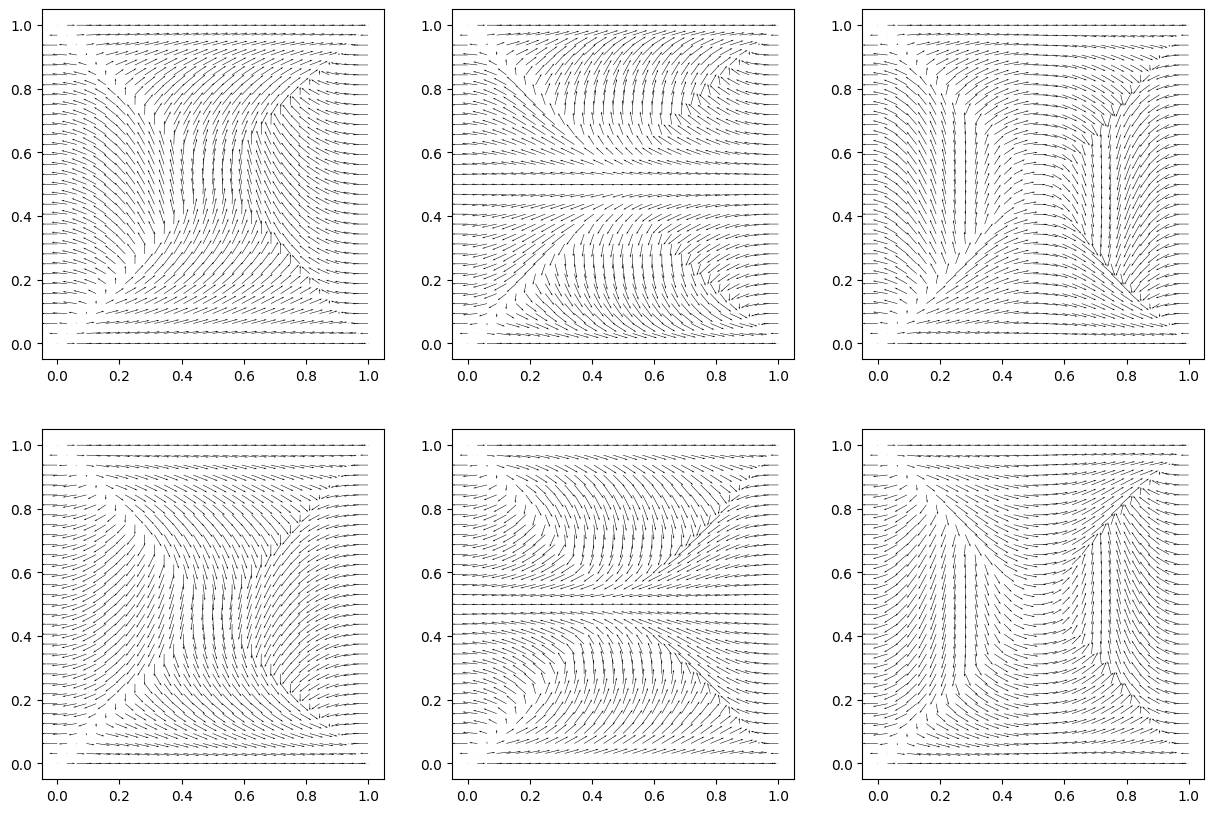

In [22]:
fig, ax = plt.subplots(2, 3)
fig.set_figheight(10)
fig.set_figwidth(15)
ax[0,0].quiver(
                x_plot, y_plot,                             
                Q11_NN_plot[0],
                Q12_NN_plot[0],      
                angles='xy', scale_units='xy', scale=20, width=0.0015
                )
ax[1,0].quiver(
                x_plot, y_plot,                             
                Q11_NN_plot[1],
                Q12_NN_plot[1],      
                angles='xy', scale_units='xy', scale=20, width=0.0015
                )
ax[0,1].quiver(
                x_plot, y_plot,                             
                Q11_NN_plot[2],
                Q12_NN_plot[2],      
                angles='xy', scale_units='xy', scale=20, width=0.0015
                )
ax[1,1].quiver(
                x_plot, y_plot,                             
                Q11_NN_plot[3],
                Q12_NN_plot[3],      
                angles='xy', scale_units='xy', scale=20, width=0.0015
                )
ax[0,2].quiver(
                x_plot, y_plot,                             
                Q11_NN_plot[4],
                Q12_NN_plot[4],      
                angles='xy', scale_units='xy', scale=20, width=0.0015
                )
ax[1,2].quiver(
                x_plot, y_plot,                             
                Q11_NN_plot[5],
                Q12_NN_plot[5],      
                angles='xy', scale_units='xy', scale=20, width=0.0015
                )

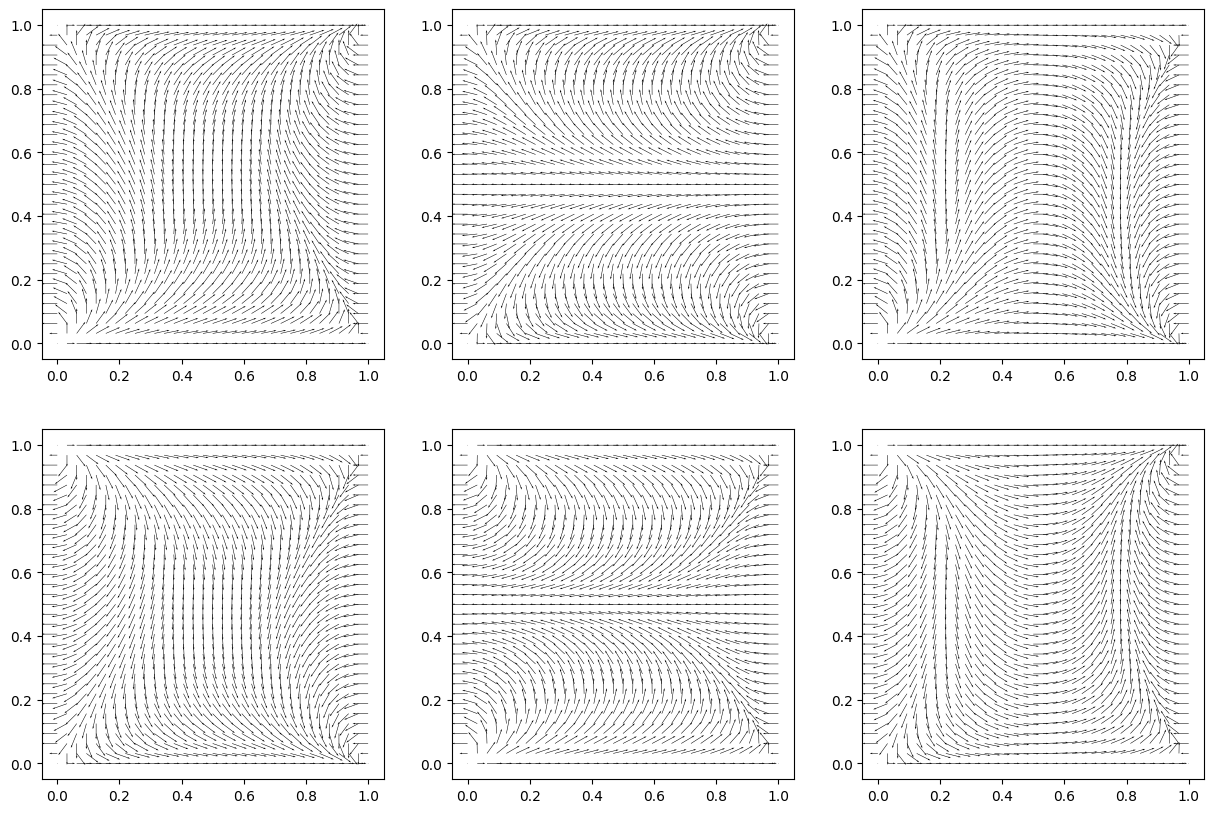

In [ ]:
fig, ax = plt.subplots(2, 3)
fig.set_figheight(10)
fig.set_figwidth(15)
ax[0,0].quiver(
                xy[:33*33,0], xy[:33*33,1],                             
                Q11_fem[0][:33*33],
                Q12_fem[0][:33*33],      
                angles='xy', scale_units='xy', scale=20, width=0.0015
                )
ax[1,0].quiver(
                xy[:33*33,0], xy[:33*33,1],                             
                Q11_fem[1][:33*33],
                Q12_fem[1][:33*33],      
                angles='xy', scale_units='xy', scale=20, width=0.0015
                )
ax[0,1].quiver(
                xy[:33*33,0], xy[:33*33,1],                             
                Q11_fem[2][:33*33],
                Q12_fem[2][:33*33],      
                angles='xy', scale_units='xy', scale=20, width=0.0015
                )
ax[1,1].quiver(
                xy[:33*33,0], xy[:33*33,1],                             
                Q11_fem[3][:33*33],
                Q12_fem[3][:33*33],      
                angles='xy', scale_units='xy', scale=20, width=0.0015
                )
ax[0,2].quiver(
                xy[:33*33,0], xy[:33*33,1],                             
                Q11_fem[4][:33*33],
                Q12_fem[4][:33*33],      
                angles='xy', scale_units='xy', scale=20, width=0.0015
                )
ax[1,2].quiver( 
                xy[:33*33,0], xy[:33*33,1],                             
                Q11_fem[5][:33*33],
                Q12_fem[5][:33*33],      
                angles='xy', scale_units='xy', scale=20, width=0.0015
                )

## Relative L2 Differences

In [25]:
xy_torch = torch.Tensor(xy).to("cuda")
modelOut4Diff = model( xy_torch)
q11_NN4Diff = modelOut4Diff["out1"]
q12_NN4Diff = modelOut4Diff["out2"]

Q11_NN4Diff = []
Q12_NN4Diff = []

Q11_NN4Diff.append(q11_NN4Diff[permutationSolutions[0]].detach().cpu().numpy())
Q12_NN4Diff.append(q12_NN4Diff[permutationSolutions[0]].detach().cpu().numpy())

Q11_NN4Diff.append(q11_NN4Diff[permutationSolutions[1]].detach().cpu().numpy())
Q12_NN4Diff.append(q12_NN4Diff[permutationSolutions[1]].detach().cpu().numpy())

Q11_NN4Diff.append(q11_NN4Diff[permutationSolutions[2]].detach().cpu().numpy())
Q12_NN4Diff.append(q12_NN4Diff[permutationSolutions[2]].detach().cpu().numpy())

Q11_NN4Diff.append(q11_NN4Diff[permutationSolutions[3]].detach().cpu().numpy())
Q12_NN4Diff.append(q12_NN4Diff[permutationSolutions[3]].detach().cpu().numpy())

Q11_NN4Diff.append(q11_NN4Diff[permutationSolutions[4]].detach().cpu().numpy())
Q12_NN4Diff.append(q12_NN4Diff[permutationSolutions[4]].detach().cpu().numpy())

Q11_NN4Diff.append(q11_NN4Diff[permutationSolutions[5]].detach().cpu().numpy())
Q12_NN4Diff.append(q12_NN4Diff[permutationSolutions[5]].detach().cpu().numpy())

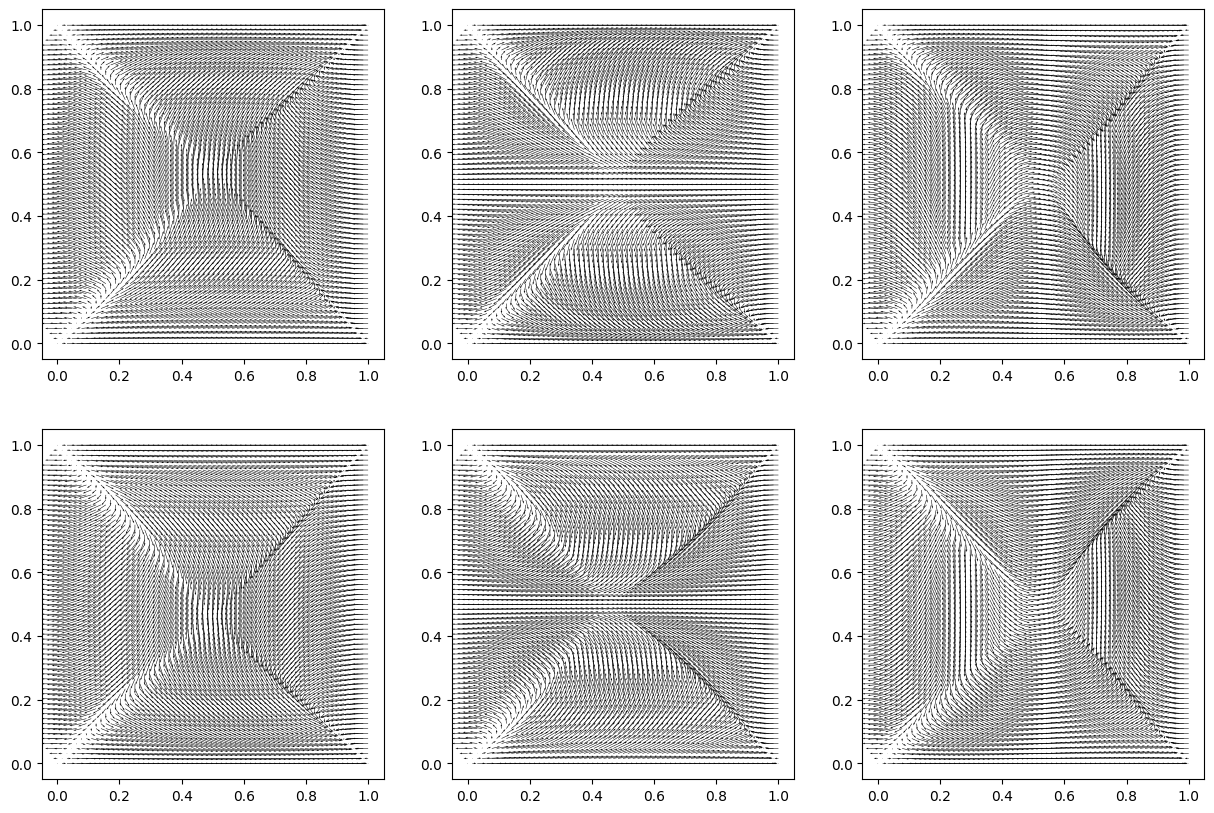

In [26]:
fig, ax = plt.subplots(2, 3)
fig.set_figheight(10)
fig.set_figwidth(15)
ax[0,0].quiver(
                xy[:,0], xy[:,1],                             
                Q11_NN4Diff[0],
                Q12_NN4Diff[0],      
                angles='xy', scale_units='xy', scale=20, width=0.0015
                )
ax[1,0].quiver(
                xy[:,0], xy[:,1],                             
                Q11_NN4Diff[1],
                Q12_NN4Diff[1],      
                angles='xy', scale_units='xy', scale=20, width=0.0015
                )
ax[0,1].quiver(
                xy[:,0], xy[:,1],                             
                Q11_NN4Diff[2],
                Q12_NN4Diff[2],      
                angles='xy', scale_units='xy', scale=20, width=0.0015
                )
ax[1,1].quiver(
                xy[:,0], xy[:,1],                             
                Q11_NN4Diff[3],
                Q12_NN4Diff[3],      
                angles='xy', scale_units='xy', scale=20, width=0.0015
                )
ax[0,2].quiver(
                xy[:,0], xy[:,1],                             
                Q11_NN4Diff[4],
                Q12_NN4Diff[4],      
                angles='xy', scale_units='xy', scale=20, width=0.0015
                )
ax[1,2].quiver(
                xy[:,0], xy[:,1],                             
                Q11_NN4Diff[5],
                Q12_NN4Diff[5],      
                angles='xy', scale_units='xy', scale=20, width=0.0015
                )

In [27]:
solutionNames = ["D1", "D2", "R1", "R2", "R3", "R4",]
for i in range(6):
    rel_diff = relative_l2_Difference(xy[:, 0], xy[:, 1],Q11_NN4Diff[i], Q12_NN4Diff[i], xy[:, 0], xy[:,1],Q11_fem[i], Q12_fem[i] )
    abs_diff = l2_Difference(xy[:, 0], xy[:, 1],Q11_NN4Diff[i], Q12_NN4Diff[i], xy[:, 0], xy[:,1],Q11_fem[i], Q12_fem[i] )
    print(f"Metrics for {solutionNames[i]}-solution:" )
    print(f"Relative L2 Distance to FEM solution: {rel_diff}")
    print(f"Absolute L2 Distance to FEM solution: {abs_diff}")
    print("----------------------------------")

Metrics for D1-solution:
Relative L2 Distance to FEM solution: 0.36760328492747707
Absolute L2 Distance to FEM solution: 0.36449206021450203
----------------------------------
Metrics for D2-solution:
Relative L2 Distance to FEM solution: 0.3679022463329944
Absolute L2 Distance to FEM solution: 0.3647884913485251
----------------------------------
Metrics for R1-solution:
Relative L2 Distance to FEM solution: 0.2972267915396159
Absolute L2 Distance to FEM solution: 0.29450816603681995
----------------------------------
Metrics for R2-solution:
Relative L2 Distance to FEM solution: 0.29352012865911126
Absolute L2 Distance to FEM solution: 0.2908354066553405
----------------------------------
Metrics for R3-solution:
Relative L2 Distance to FEM solution: 0.29665744073421024
Absolute L2 Distance to FEM solution: 0.29394402287643046
----------------------------------
Metrics for R4-solution:
Relative L2 Distance to FEM solution: 0.29801387483212094
Absolute L2 Distance to FEM solution: 0.2